In [1]:
#Read de data from a json file
import json
from glob import glob
import pandas as pd
import numpy as np

def read_json(file):
    with open(file) as f:
        data = json.load(f)
    return data

In [4]:
data = read_json('metrics_resume.json')

JSONDecodeError: Expecting value: line 1 column 3111 (char 3110)

In [20]:
dateList = data['PPO Agent']['dates']
initial_balance = 100000
agents = list(data.keys())
agents

['PPO Agent', 'A2C Agent', 'DDPG Agent', 'Random Agent', 'SP500 Agent']

In [52]:
dateList

['2018-01-01']

['2018-01-02',
 '2018-01-29',
 '2018-02-23',
 '2018-03-21',
 '2018-04-17',
 '2018-05-11',
 '2018-06-07',
 '2018-07-03',
 '2018-07-30',
 '2018-08-23',
 '2018-09-19',
 '2018-10-15',
 '2018-11-08',
 '2018-12-06',
 '2019-01-03',
 '2019-01-30',
 '2019-02-26',
 '2019-03-22',
 '2019-04-17',
 '2019-05-14',
 '2019-06-10',
 '2019-07-05',
 '2019-07-31',
 '2019-08-26',
 '2019-09-20',
 '2019-10-16',
 '2019-11-11',
 '2019-12-06',
 '2020-01-03',
 '2020-01-30',
 '2020-02-26',
 '2020-03-23',
 '2020-04-17',
 '2020-05-13',
 '2020-06-09',
 '2020-07-06',
 '2020-07-30',
 '2020-08-25',
 '2020-09-21',
 '2020-10-15',
 '2020-11-10',
 '2020-12-07',
 '2021-01-04',
 '2021-01-29',
 '2021-02-25',
 '2021-03-23',
 '2021-04-19',
 '2021-05-13',
 '2021-06-09',
 '2021-07-06']

In [17]:
agent_name = agents[0]
agent_data = data[agent_name]

In [21]:
net_worths_delta_list = agent_data['net_worths_delta']

In [39]:
returns_list_multip = [1] + [(delta/initial_balance)+1 for delta in net_worths_delta_list]

In [48]:
returns_list_multip
final_balances = []
for i in range(len(returns_list_multip)):
    final_balances.append(np.prod(returns_list_multip[:i+1])*initial_balance)

In [50]:
for agent_name in agents:
    agent_data = data[agent_name]
    net_worths_delta_list = agent_data['net_worths_delta']
    returns_list_multip = [1] + [(delta/initial_balance)+1 for delta in net_worths_delta_list]
    returns_list_multip
    final_balances = []
    for i in range(len(returns_list_multip)):
        final_balances.append(np.prod(returns_list_multip[:i+1])*initial_balance)
    data[agent_name]['final_balance'] = final_balances


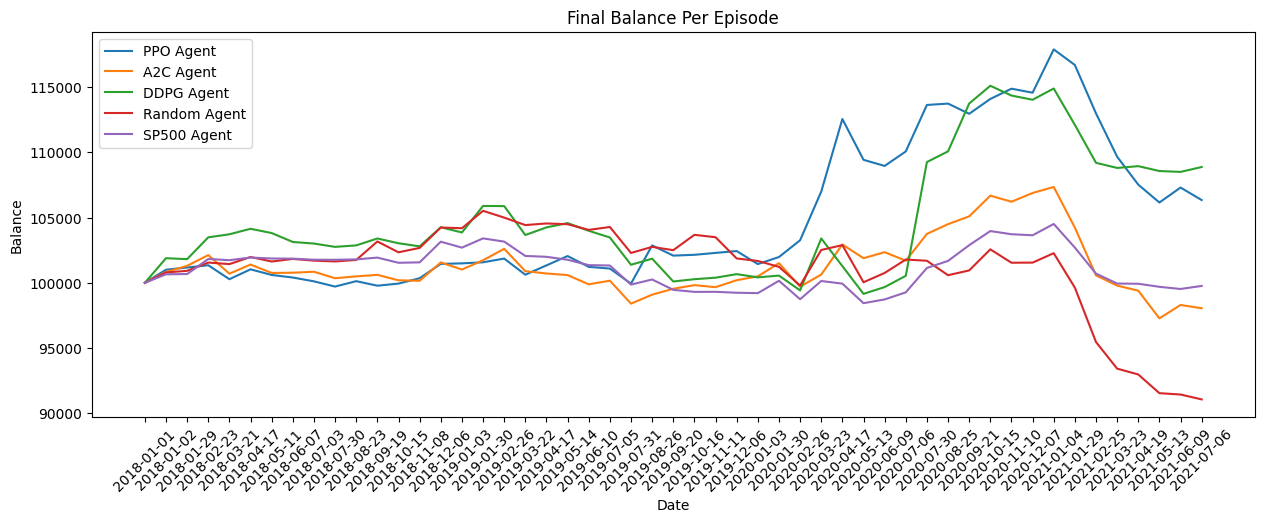

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for agent_name, agent_metrics in data.items():
    plt.plot(['2018-01-01'] + agent_metrics['dates'], agent_metrics['final_balance'], label=agent_name)
plt.xticks(rotation=45)
plt.title('Final Balance Per Episode')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.legend()
plt.show()